## Libraries

In [19]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys, os
import shap
shap.initjs() # Inicializa la visualización de SHAP

# Ruta del directorio donde está el notebook
notebook_dir = os.getcwd()
# Sube un nivel para llegar a la raíz del proyecto
project_root = os.path.dirname(notebook_dir)
# Añade la carpeta raíz al path
sys.path.append(project_root)
from IPython.display import display, IFrame
from sklearn.model_selection import train_test_split
from src.Data_Preprocessing import preprocessing, balance_data
from src.Modeling_SVM import svm_model, best_svm, curva_roc, evaluate_svm
from src.Modeling_NN import train_nn_baseline, train_nn_tuned, plot_roc_curve, KerasProbaWrapper, compute_shap_forceplot
from src.Modeling_XGBoost import xgboost_model, xgboost_hyperparameter_tuning, roc_curve_xgboost, var_importance_xgboost
from src.Interpretation_of_Variables import permutation_imp, shap_for_svm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Data Reading
This dataset contains financial realated information from clients of a bank. They realized that in the last quarter, there has been a client reduction of 15% leading to the need for understanding the type of client that is churning and to predict what clients are more likely to churn

In [20]:
df = pd.read_excel(r"C:\Users\LENOVO\Documents\D\Documentos\Javeriana\IX semestre\Analítica 2\Proyecto_Final\data\bank_churn.xlsx")

## Data Preprocessing
This module cleans and transforms data for the proper manipulation afterwards. The preprocessing function maps binary variables converting them into 1 and 0; it applies one-hot encoding (get_dummies) to categorical variables; drops the clientnum because it is not relevant for the proyect and returns X: all remained variables and Y: atrrition_flag --> if the client remains in the company (0) or gets churned (1)

In [21]:
x,y = preprocessing(df)

Preprocessing completed: Data cleaned and transformed. 

Y proportion: 
attrition_flag
0    0.83934
1    0.16066
Name: proportion, dtype: float64 



### Split

In [22]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size=0.2, random_state=472)

### Balancing 
The function does balancing using imblearn in order to prevent overfitting due to the imbalance showe earlier

In [23]:
x_balanced, y_balanced = balance_data(X_train,Y_train,sampling_strategy=0.5,method='smotetomek')

Data balancing completed: Applied smotetomek with sampling strategy 0.5. 

Y_balanced proportion: 
 attrition_flag
0    0.673547
1    0.326453
Name: proportion, dtype: float64


## Data Modeling

### SVM
This section runs two SVM models, one with default parameters and the other one performs GridSearch for hyperparemeter tuning in order to find the best combination of hyperparameters. It returns the model, the curve roc plot and the corresponding metrics including a confusion matrix to understand how is the prediction in both classes (0 and 1)

#### Base model

Training SVM Classifier...

SVM Classifier metrics report:
               precision    recall  f1-score   support

           0       0.94      0.96      0.95      1706
           1       0.77      0.66      0.71       320

    accuracy                           0.92      2026
   macro avg       0.86      0.81      0.83      2026
weighted avg       0.91      0.92      0.91      2026
 

Confusion Matrix:
 [[1644   62]
 [ 108  212]]


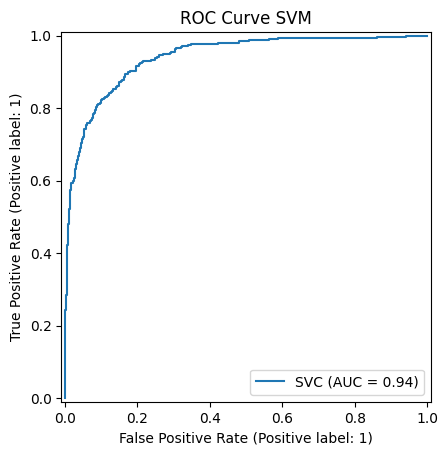

In [24]:
svm_model, X_test_sc_svm, Y_test_svm = svm_model(x_balanced, y_balanced ,X_test, Y_test)
curva_roc(svm_model, X_test_sc_svm, Y_test_svm, show=True)

#### Tuned model

Best hyperparameters found: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
SVM Classifier metrics report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      1706
           1       0.79      0.71      0.75       320

    accuracy                           0.92      2026
   macro avg       0.87      0.84      0.85      2026
weighted avg       0.92      0.92      0.92      2026
 

Confusion Matrix:
 [[1644   62]
 [  93  227]]


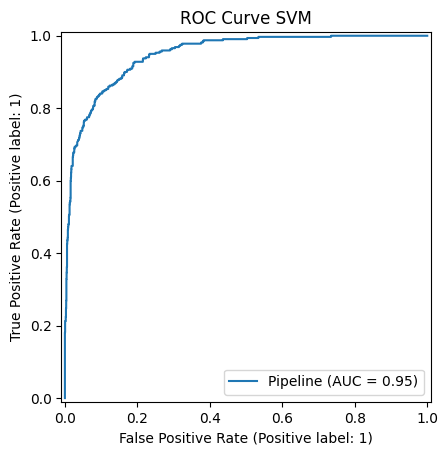

In [25]:
svm_tuned, best_params = best_svm(x_balanced, y_balanced)
metrics, report = evaluate_svm(svm_tuned, X_test, Y_test)
curva_roc(svm_tuned, X_test, Y_test, show=True)

The tuned model presents a better performance in the positive class: it reduces the false negatives (108 --> 93) and it increments the true positives (212 --> 227). In business applied terms, the tuned model identifies 11 additional churn clients, showing a better trade-off.

### Neural Network
This section runs two Neural Networks: a base model and another one using hyperparameter tunning to improve the performance, the tuning runs a grid of different values for the parameters and returns the best ones. The module also returns the metrics (including a confusion matrix) and it has the roc curve plot function to evalute the performance of the model

### Base NN

In [26]:
nn_base, nn_scaler_base, nn_base_metrics = train_nn_baseline(
    x_balanced, y_balanced,
    X_test, Y_test,
    hidden_units=[128,64],
    dropout=0.2,
    l2_reg=1e-4,
    lr=1e-3,
    epochs=50
)

print(nn_base_metrics["report"])
print(nn_base_metrics["confusion_matrix"])


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1706
           1       1.00      0.05      0.10       320

    accuracy                           0.85      2026
   macro avg       0.92      0.53      0.51      2026
weighted avg       0.87      0.85      0.79      2026

[[1706    0]
 [ 303   17]]


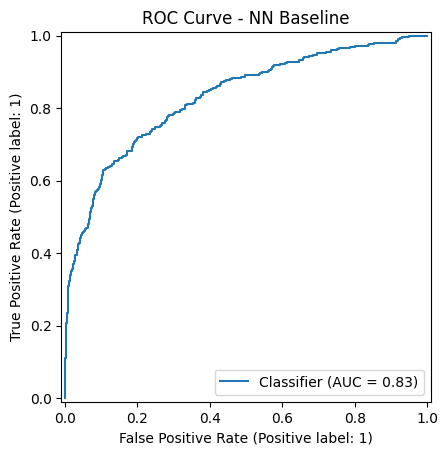

In [27]:
plot_roc_curve(
    nn_base,
    nn_scaler_base,
    X_test,
    Y_test,
    title="ROC Curve - NN Baseline"
)

#### Tuned NN

In [28]:
nn_tuned, nn_scaler_tuned, nn_tuned_metrics, nn_best_params = train_nn_tuned(
    x_balanced, y_balanced,
    X_test, Y_test,
    hidden_grid=[[128,64],[64,32],[128,64,32]],
    dropout_grid=[0.0,0.2,0.4],
    l2_grid=[0.0,1e-4],
    lr_grid=[1e-3,5e-4],
    batch_grid=[128],
    epochs=60
)

print("Best params:", nn_best_params)
print(nn_tuned_metrics["report"])
print(nn_tuned_metrics["confusion_matrix"])


Starting hyperparameter tuning for Neural Network...

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
46/46 ━━━━

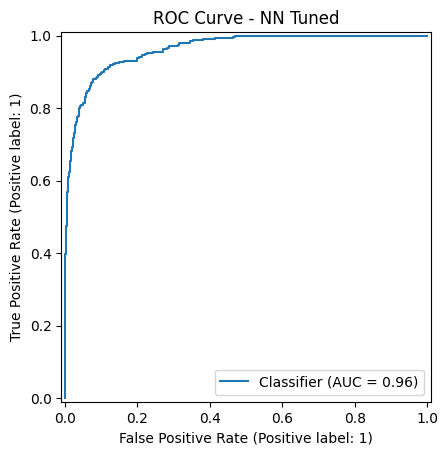

In [29]:
plot_roc_curve(
    nn_tuned,
    nn_scaler_tuned,
    X_test,
    Y_test,
    title="ROC Curve - NN Tuned"
)

The tuned model outperformed the base nn model, it reduces the quantity of false negatives (303 --> 76) and que true positives increased from 17 to 244. These results, adding the rou_auc_score, even outperformed the SVM tuned.

### XGBoost
This section runs a module for the XGBoost model, it has a base model and another one with hyperparameter tuning using RandomizedSearchCV. The module also has a roc curve plot function to analyze the performance of the model

#### Base model

c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [22:24:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier metrics report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1706
           1       0.94      0.87      0.90       320

    accuracy                           0.97      2026
   macro avg       0.96      0.93      0.94      2026
weighted avg       0.97      0.97      0.97      2026
 

Confusion Matrix:
 [[1689   17]
 [  42  278]]


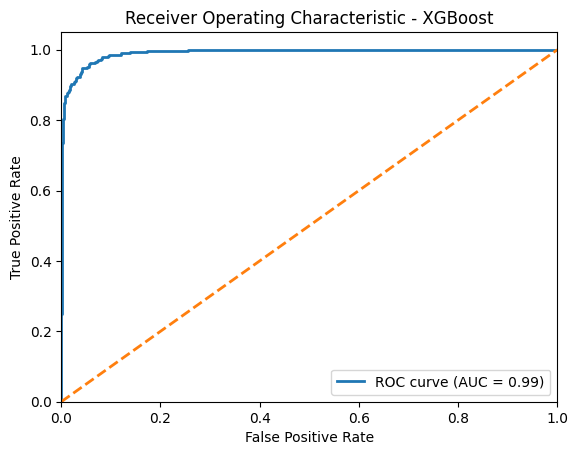

In [30]:
xgb_model = xgboost_model(X_train, Y_train, X_test, Y_test)
roc_curve_xgboost(xgb_model, X_test, Y_test, show=True)

#### Tuned model

Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\LENOVO\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:199: UserWarning: [22:24:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost tuned best hyperparameters found: {'subsample': 0.6, 'n_estimators': 150, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 0.6} 

XGBoost tuned Classifier metrics report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.98      1706
           1       0.92      0.88      0.90       320

    accuracy                           0.97      2026
   macro avg       0.95      0.94      0.94      2026
weighted avg       0.97      0.97      0.97      2026
 

Confusion Matrix:
 [[1683   23]
 [  37  283]]


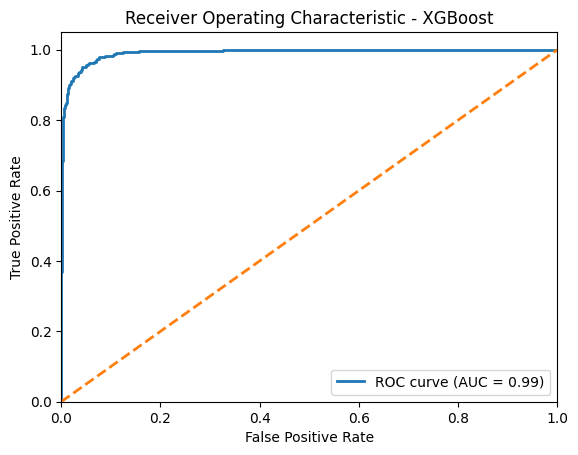

In [31]:
xg_boost_tuned, xgb_best_params = xgboost_hyperparameter_tuning(x_balanced, y_balanced, X_test, Y_test)
roc_curve_xgboost(xg_boost_tuned, X_test, Y_test, show=True)


The tuned model outperformed the base xgboost model, it reduces the quantity of false negatives (42 --> 37) and que true positives increased from 278 to 283. These results, adding the rou_auc_score, even outperformed the NN tuned and the SVM tuned. This is **the best** model out of the framework evaluated in this project

## Variables explanation

### XGBoost

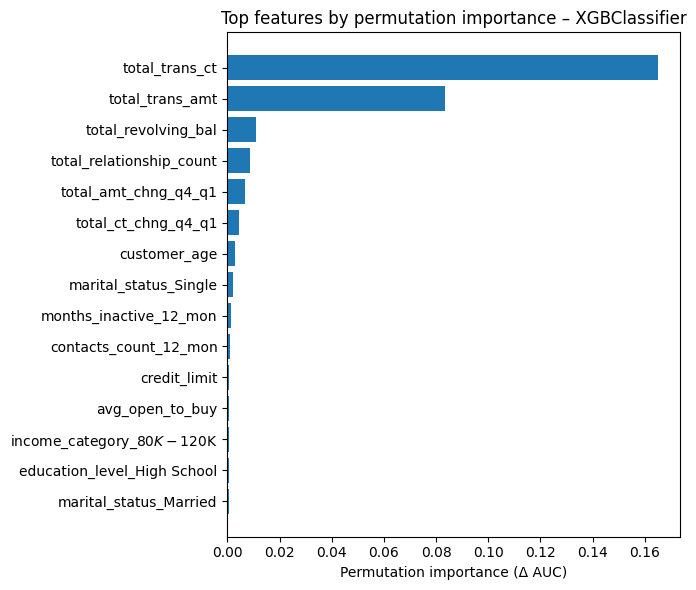

In [33]:
permutation_imp(xg_boost_tuned, X_test, Y_test)

The permutation importance for XGBoost tuned showed that the 'total_trans_ct', 'total_trans_amt' and 'total_revolving_bal' variables are the most important, meaning that if they change, the performance of the model can be worsen the AUC up to 0.16 points  

### SVM

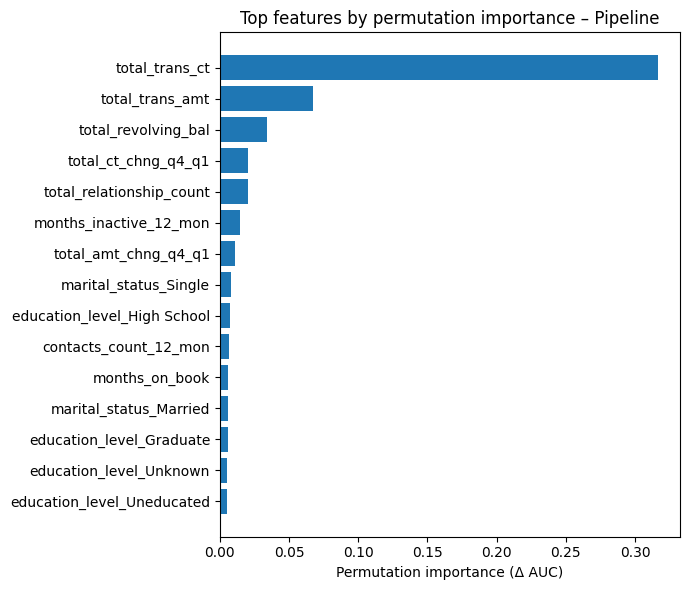

In [34]:
permutation_imp(svm_tuned, X_test, Y_test, show=True)

100%|██████████| 50/50 [15:31<00:00, 18.63s/it]


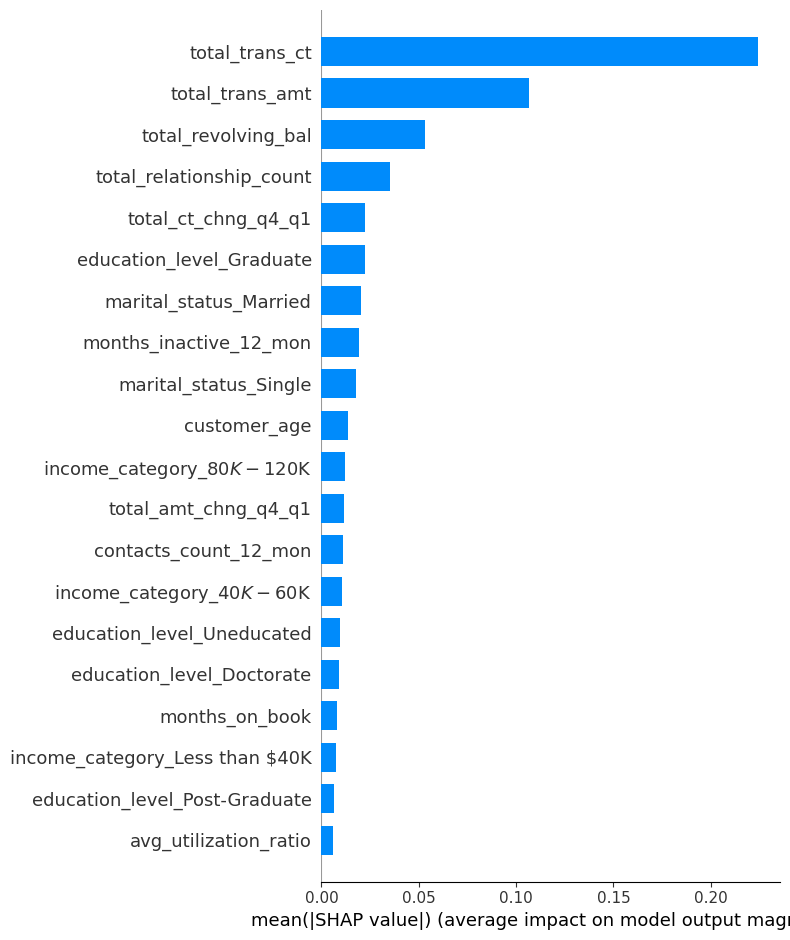

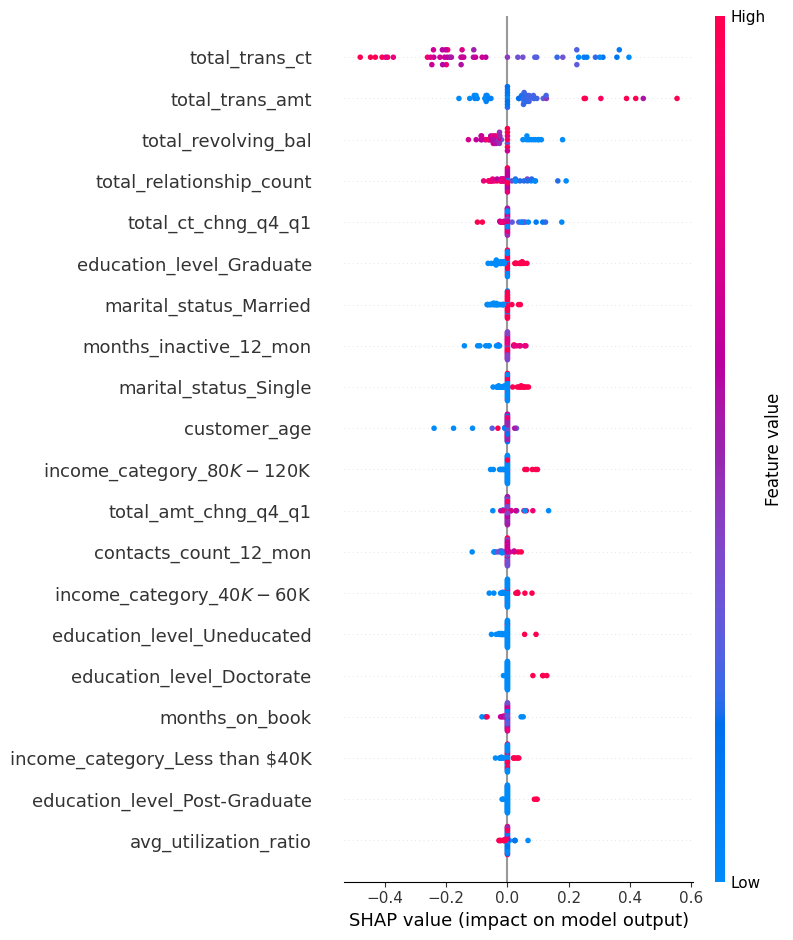

In [35]:
shap_for_svm(svm_tuned, x_balanced, X_test)

### NN

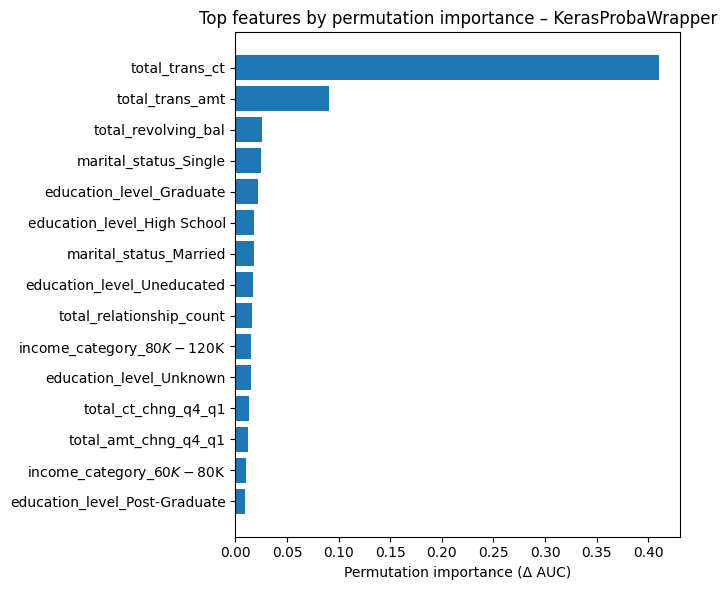

In [36]:
permutation_imp(nn_tuned, X_test, Y_test, scaler= nn_scaler_tuned, show=True)

In [37]:
sv, exp, Xs, fp = compute_shap_forceplot(
    model=nn_tuned,
    scaler=nn_scaler_tuned,
    X_train=X_train,
    X_test=X_test,
    wrapper_cls=KerasProbaWrapper,
    class_index=1,
    save_html="shap_force.html",
    return_plot=True
)

100%|██████████| 100/100 [00:55<00:00,  1.80it/s]


In [38]:
display(fp)                       # o:
IFrame("shap_force.html", 80, 50)

**- The red color represents features that are more likely to increase the probability of churn (class: 1)**

**- The blue color represents features that are more likely to decrease the probability of churn (class: 0 )**

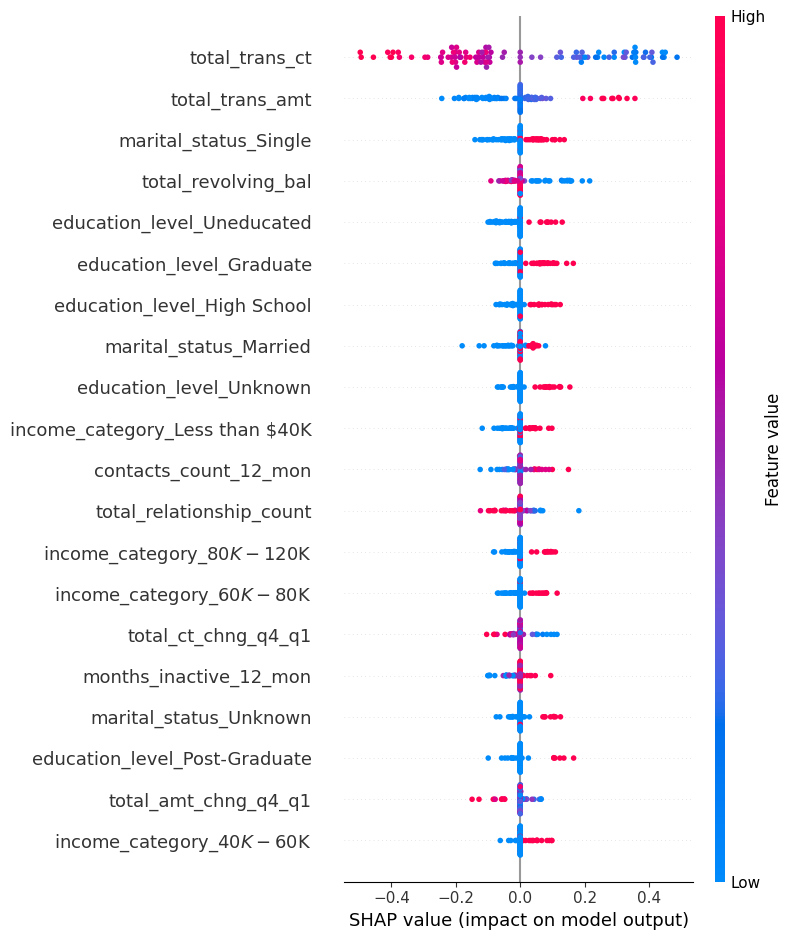

In [39]:
# Gráfico estático:
shap.summary_plot(sv, Xs)         # global
i = 0
ex_i = shap.Explanation(values=sv[i], base_values=exp,data=Xs.iloc[i].values, feature_names=Xs.columns.tolist())

In this model, the variables that most increase the probability of churn are those linked to extreme or unstable transactional behavior and specific demographic segments. High values of **total_trans_ct** and **total_trans_amt** significantly raise **churn risk**, suggesting that customers with unusually intense activity may be preparing to close their accounts. Strong changes in transaction volume (total_ct_chng_q4_q1) and longer periods of inactivity (months_inactive_12_mon) also push the model toward higher churn predictions, reflecting both abrupt behavioral shifts and sustained lack of use. Additionally, the demographic feature marital_status_Single emerges as a strong contributor to churn, indicating that single customers are more likely to leave the bank.

Conversely, the variables that most reduce churn reflect stable engagement and an active relationship with the institution. Higher revolving balances (**total_revolving_bal**) decrease the probability of churn, potentially because these customers maintain financial commitments that keep them tied to the bank. Likewise, a higher number of interactions with the bank in the past year (**contacts_count_12_mon**) is strongly associated with lower churn, suggesting that frequent touchpoints support retention. Finally, higher educational levels, such as **education_level_Graduate** and **education_level_Post-Graduate**, tend to correlate with reduced churn risk, indicating a more stable or predictable customer relationship.

## Overall Summary
The best model found was the **XGBoost tuned**, showing the slowest quantity of **false negatives** and the highest quantity of **true positives** for the positive class (churn). It also had the highest AUC (0.99). Additionally, the permutation importance of this model showed that the **'total_trans_ct'**, **'total_relationship_count'** and **'total_revolving_bal'** variables are the most relevant in terms of the model performance, leading to a slight decrease if they change their values. Likewise, the same permutation importance and Shap Values evaluation, showed that for all models, the variables **'total_trans_ct'**, **'total_trans_amt'** are the most relevant, in terms of Shap Values, they are the most likely to raise the probability of **churn risk** 